## From Estimation to Practical Application

### Abstract

This post explores meta-learners (S-, T-, and X-learners) for estimating heterogeneous treatment effects (CATE) on a public experimental dataset. The focus is not just on implementation, but on understanding how these methods behave in practice, how they compare to classical approaches, and when they provide reliable insights for decision-making.

---

This analysis examines how meta-learners can be used to estimate treatment effects at the individual and segment level.

Rather than treating these models as black-box estimators, the goal is to understand:

- how different learners capture heterogeneity  
- how they compare to traditional ATE estimation approaches  
- when their estimates are stable and interpretable  
- what diagnostics are necessary before trusting the results  

---

## Data and setup

We use the RAND Health Insurance Experiment dataset (via `statsmodels`), a well-known experimental dataset that allows clean evaluation of treatment effects under randomized assignment.

The analysis includes:

- ATE vs CATE estimation  
- propensity score modeling and overlap checks  
- matching (PSM) and weighting (IPTW)  
- meta-learners (S-, T-, and X-learners)  
- diagnostic checks and validation tests  

---

## Framing

The goal is not to compare models in isolation, but to understand how different approaches behave when used for estimating and interpreting heterogeneous treatment effects.

In particular:

- when simpler methods are sufficient  
- when meta-learners provide additional insight  
- how to validate whether estimated heterogeneity is meaningful  

---

## Core question

> When estimating heterogeneous treatment effects, how do meta-learners compare to classical approaches, and when can their results be trusted in practice?
## References

- Molak, A. *Causal Inference and Discovery in Python*. Packt Publishing.
- RAND Health Insurance Experiment dataset (via `statsmodels`)

## 0) Setup

We’ll use:
- `statsmodels` for the bundled RAND HIE dataset (no download needed)
- `pandas/numpy` for data handling
- `scikit-learn` for propensity + outcome models
- `matplotlib` for plots


In [20]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

np.random.seed(42)


## 1) Load a public dataset (RAND HIE)

Dataset: **RAND Health Insurance Experiment** (`statsmodels.datasets.randhie`).

We’ll define a binary treatment `T` from `lncoins` (log coinsurance rate):
- **T = 1** → more generous insurance (lower coinsurance)
- **T = 0** → less generous insurance (higher coinsurance)

Outcome `Y`: `mdvis` (outpatient medical visits)

Covariates `X`: a small set of health + socio-economic variables.


In [21]:
df = sm.datasets.randhie.load_pandas().data.copy()
print("Shape:", df.shape)
df.head()


Shape: (20190, 10)


,mdvis,lncoins,idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
0,0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
1,2,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
2,0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
3,0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
4,0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0



### Why use **mean** (not median) to define treatment?

In the original RAND HIE context, *lower coinsurance* means a **more generous insurance plan** (you pay a smaller share out-of-pocket).  
To turn this into a clean “treated vs. control” demo, we need a threshold on `lncoins`:

- **Treatment (T=1):** lower-than-threshold coinsurance ⇒ *more generous plan*  
- **Control (T=0):** higher-than-threshold coinsurance ⇒ *less generous plan*

Here we use the **mean** of `lncoins` as the cutoff.  
In practice, the choice of cutoff is a modeling decision:
- **Median** gives equal group sizes (often stable).
- **Mean** can create imbalance if the variable is skewed (and imbalance matters for T‑ and X‑Learner behavior).

Because work is about *why different learners behave differently under imbalance*, it’s actually useful to see what happens when the split is not perfectly balanced.


In [22]:
mean_lncoins = df["lncoins"].mean()
df["T"] = (df["lncoins"] < mean_lncoins).astype(int)  # 1 = lower coinsurance (more generous)

df["Y"] = df["mdvis"].astype(float)

X_cols = ["lpi", "fmde", "physlm", "disea", "hlthg", "hlthf", "hlthp"]
df[["Y", "T"] + X_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Y,20190.0,2.860426,4.504365,0.0,0.000000,1.000000,4.000000,77.000000
T,20190.0,0.544676,0.498012,0.0,0.000000,1.000000,1.000000,1.000000
lpi,20190.0,4.707894,2.697840,0.0,4.063885,6.109248,6.620073,7.163699
fmde,20190.0,4.029524,3.471353,0.0,0.000000,6.093520,6.959049,8.294049
physlm,20190.0,0.123500,0.322016,0.0,0.000000,0.000000,0.000000,1.000000
disea,20190.0,11.244492,6.741449,0.0,6.900000,10.576260,13.731890,58.600000
hlthg,20190.0,0.362011,0.480594,0.0,0.000000,0.000000,1.000000,1.000000
hlthf,20190.0,0.077266,0.267020,0.0,0.000000,0.000000,0.000000,1.000000
hlthp,20190.0,0.014958,0.121387,0.0,0.000000,0.000000,0.000000,1.000000


### Descriptive check (not causal yet)
Compare raw mean outcomes between treated and control.


In [23]:
df.groupby('T')['Y'].agg(['count','mean','std'])

,count,mean,std
T,,,
0,9193,2.545633,4.229660
1,10997,3.123579,4.705815


## 2) Causal framing 

### The two “levels” of causal questions

**ATE (Average Treatment Effect)** answers:

- “If everyone moved from control → treatment, what would the *average* change be?”

\[
ATE = E[Y(1) - Y(0)]
\]

**HTE / CATE (Heterogeneous Treatment Effect)** answers:

- “Does the effect differ across people with different features `X`?”
- “For a person with characteristics `x`, what is the expected effect?”

\[
	tau(x) = E[Y(1) - Y(0)| X=x]
\]

In marketing terms, **ATE** is “Does the campaign work on average?”  
**CATE/HTE** is “Who is persuadable / who benefits most?” (targeting / uplift).

### The key assumption (what makes any of this possible)

All methods in this notebook rely (explicitly or implicitly) on:

> **Conditional ignorability / unconfoundedness:**  
> given measured covariates `X`, treatment assignment is “as‑if random”.

That means: after adjusting for `X`, there are no *unmeasured confounders* that jointly affect `T` and `Y`.

If this assumption fails, matching/weighting/meta‑learners can still produce numbers—but they may not be causal.

### Why propensity scores show up everywhere in this analysis

The propensity score `e(x)=P(T=1|X=x)` helps with:

- **Overlap diagnostics** (do treated/control mix over the same covariate region?)
- **Matching** (pair treated to similar controls)
- **Weighting** (reweight to create a pseudo‑population where treatment is “balanced”)

Now we’ll compute `e(x)` and check overlap.


## 3) Train/test split (for model stability)

Train/test split does **not** validate causal correctness,  
but it helps reduce overfitting when learning CATE models.


In [24]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["T"])

X_train, T_train, Y_train = train_df[X_cols], train_df["T"].values, train_df["Y"].values
X_test,  T_test,  Y_test  = test_df[X_cols],  test_df["T"].values,  test_df["Y"].values

train_df.shape, test_df.shape


((16152, 12), (4038, 12))

## 4) Propensity scores + overlap

### What is the propensity score?

\[
e(x) = P(T=1| X=x)
\]

Interpretation: for someone with covariates `x` (income, age, etc.), how likely are they to be in the treated group?

### Why overlap matters (the “no extrapolation” rule)

Even if you estimate `e(x)` perfectly, causal estimation becomes unstable if:

- treated units have `e(x)` near **1** (almost always treated)
- control units have `e(x)` near **0** (almost never treated)

Because then the model must **extrapolate** counterfactuals in regions with no data.

So we always:
1. Fit a propensity model  
2. Plot distributions of `e(x)` for treated vs control  
3. Optionally trim/extreme‑weight clip if overlap is poor

In the plots below, you want to see:
- substantial overlap between treated and control propensity distributions
- not too many probabilities extremely close to 0 or 1


In [25]:
propensity_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

propensity_model.fit(X_train, T_train)
ps_train = propensity_model.predict_proba(X_train)[:, 1]
ps_test  = propensity_model.predict_proba(X_test)[:, 1]

print("Propensity AUC (train):", roc_auc_score(T_train, ps_train))
print("Propensity AUC (test) :", roc_auc_score(T_test,  ps_test))


Propensity AUC (train): 0.899601574899925
Propensity AUC (test) : 0.879640283375631


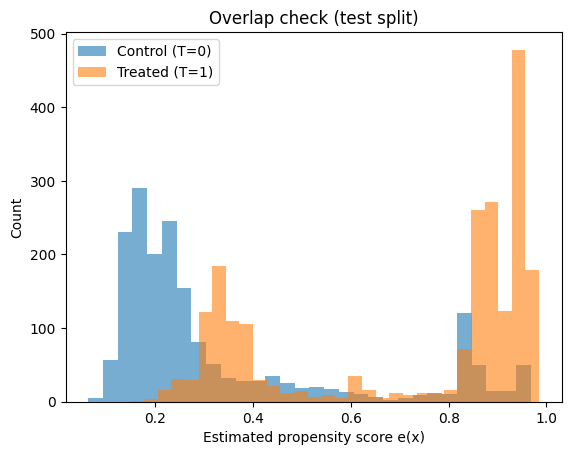

PS range control: (np.float64(0.06305527698131999), np.float64(0.967711808907784))
PS range treated: (np.float64(0.14956967160707563), np.float64(0.984931041276022))


In [26]:
plt.figure()
plt.hist(ps_test[T_test==0], bins=30, alpha=0.6, label="Control (T=0)")
plt.hist(ps_test[T_test==1], bins=30, alpha=0.6, label="Treated (T=1)")
plt.xlabel("Estimated propensity score e(x)")
plt.ylabel("Count")
plt.title("Overlap check (test split)")
plt.legend()
plt.show()

print("PS range control:", (ps_test[T_test==0].min(), ps_test[T_test==0].max()))
print("PS range treated:", (ps_test[T_test==1].min(), ps_test[T_test==1].max()))



## 5) ATE via Propensity Score Matching (PSM)

### Intuition

PSM tries to mimic a randomized experiment by pairing each treated unit with a control unit that has a very similar propensity score.

Workflow:

1. Estimate propensity scores `e(x)`
2. For each treated unit, find the nearest control in propensity space (1:1 matching)
3. Compute individual differences `Y_treated - Y_control`
4. Average them → estimated ATE (more precisely, ATT/ATE depending on matching scheme)

### What to look for in results

- If the matched pairs are truly similar, the **covariate balance** should improve.
- The estimated effect should be *directionally* consistent with IPW (next section),
  though they won’t match exactly because the estimands can differ (ATT vs ATE).

Limitations:
- Matching quality depends heavily on overlap and on how you match (calipers, replacement, etc.).
- You discard information (unmatched controls).


In [27]:
def propensity_score_matching_ate(df_in, ps, outcome_col="Y", treat_col="T"):
    d = df_in.reset_index(drop=True).copy()
    d["ps"] = ps

    treated = d[d[treat_col] == 1].copy()
    control = d[d[treat_col] == 0].copy()

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[["ps"]].values)

    distances, idx = nn.kneighbors(treated[["ps"]].values)
    matched_control = control.iloc[idx.flatten()].copy()
    matched_control.index = treated.index

    ate_hat = (treated[outcome_col] - matched_control[outcome_col]).mean()
    return ate_hat, distances.flatten()

ate_psm, match_dists = propensity_score_matching_ate(train_df, ps_train)
ate_psm


np.float64(0.7292566492384633)

In [28]:
pd.Series(match_dists).describe()

count    8798.000000
mean        0.000623
std         0.001017
min         0.000000
25%         0.000094
50%         0.000295
75%         0.000717
max         0.017219
dtype: float64


## 6) ATE via IPW (Inverse Propensity Weighting)

### Intuition

Instead of pairing units, IPW reweights the dataset so treated and control groups become comparable.

If someone has:
- high probability of being treated but is **control**, they get a large weight (rare event)
- low probability of being treated but is **treated**, they get a large weight (rare event)

This produces a “pseudo‑population” where treatment is independent of `X` (approximately).

### Stabilized weights (used here)

- treated:  \( w = P(T=1) / e(x) \)
- control:  \( w = P(T=0) / (1-e(x)) \)

Then:

\[
ATE ~ E_w[Y|T=1] - E_w[Y|T=0]
\]

### Practical warnings

- If `e(x)` is near 0 or 1, weights explode → high variance.
- Trimming/clipping weights is common in practice.
- Always check **balance** after weighting (next section).


In [29]:
def iptw_ate(Y, T, ps, stabilized=True, clip=(0.01, 0.99)):
    ps = np.clip(ps, clip[0], clip[1])
    p_t = T.mean()

    if stabilized:
        w = np.where(T == 1, p_t/ps, (1-p_t)/(1-ps))
    else:
        w = np.where(T == 1, 1/ps, 1/(1-ps))

    y1 = np.sum(w[T==1]*Y[T==1]) / np.sum(w[T==1])
    y0 = np.sum(w[T==0]*Y[T==0]) / np.sum(w[T==0])
    return y1 - y0, w

ate_iptw, w_train = iptw_ate(Y_train, T_train, ps_train, stabilized=True)
ate_iptw


np.float64(0.5364296626917167)

In [30]:
pd.Series(w_train).describe(percentiles=[0.5,0.9,0.95,0.99])

count    16152.000000
mean         0.975348
std          1.082926
min          0.485941
50%          0.609900
90%          1.709772
95%          2.536547
99%          5.699585
max         14.101120
dtype: float64

count    16152.000000
    mean         0.975348
    std          1.082926
    min          0.485941
    50%          0.609900
    90%          1.709772
    95%          2.536547
    99%          5.699585
    max         14.101120
    dtype: float64


## 7) Covariate balance check (Standardized Mean Differences)

After matching/weighting, we need to verify we actually reduced confounding **in the observed covariates**.

A common quick metric is **SMD** (Standardized Mean Difference).

- Before adjustment: large |SMD| means treated/control differ a lot on that covariate.
- After IPW: |SMD| should shrink toward 0.

Rule of thumb (varies by field):
- |SMD| < 0.1 is often considered “good balance”

This does **not** prove ignorability (unobserved confounding can still exist),
but it’s a necessary sanity check: if balance doesn’t improve, the causal estimate is not credible.


In [31]:
def standardized_mean_diff(x, t, w=None):
    x = np.asarray(x); t = np.asarray(t)
    if w is None:
        m1, m0 = x[t==1].mean(), x[t==0].mean()
        v1, v0 = x[t==1].var(ddof=1), x[t==0].var(ddof=1)
    else:
        w = np.asarray(w)
        def wmean(a, ww): return np.sum(ww*a)/np.sum(ww)
        def wvar(a, ww):
            mu = wmean(a, ww)
            return np.sum(ww*(a-mu)**2)/np.sum(ww)
        m1, m0 = wmean(x[t==1], w[t==1]), wmean(x[t==0], w[t==0])
        v1, v0 = wvar(x[t==1], w[t==1]), wvar(x[t==0], w[t==0])

    pooled_sd = np.sqrt(0.5*(v1+v0))
    return (m1 - m0) / pooled_sd if pooled_sd > 0 else 0.0

rows = []
for c in X_cols:
    rows.append([c,
                 standardized_mean_diff(train_df[c].values, T_train, w=None),
                 standardized_mean_diff(train_df[c].values, T_train, w=w_train)])

bal = pd.DataFrame(rows, columns=["covariate","SMD_raw","SMD_IPTW"])
bal


,covariate,SMD_raw,SMD_IPTW
0,lpi,-0.953624,-0.099442
1,fmde,-1.637897,-0.106434
2,physlm,0.035886,0.036546
3,disea,-0.072682,-0.023675
4,hlthg,-0.013260,-0.047128
5,hlthf,0.014376,0.000471
6,hlthp,0.085408,0.017549


## 8) Meta‑learners for CATE/HTE (S, T, X)

Now we move from “single number” (ATE) to **individualized effects**.

### What is HTE?

**HTE = Heterogeneous Treatment Effects**  
Same as **CATE**: the treatment effect depends on `X`.

Example: the effect might be larger for low‑income individuals than high‑income individuals.

### S‑Learner (one model)

Fit one model for the outcome:

\[
&micro;(x,t) ~ E[Y |X=x, T=t]
\]

Then predict:

\[
	tau(x) = &micro;(x,1) - &micro;(x,0)
\]

**Risk:** the model can “ignore” `T` if the signal is weak relative to `X`.

### T‑Learner (two models)

Fit two separate models:

- \(&micro;_1(x) ~ E[Y |X=x, T=1]\)
- \(&micro;_0(x) ~ E[Y |X=x, T=0]\)

Then:

\[
	tau(x) = &micro;_1(x) - &micro;_0(x)
\]

**Strength:** cannot ignore treatment  
**Weakness:** each model sees less data → can be noisy when sample sizes are small or imbalanced.

### X‑Learner (5 models including treatment propensity model)

X‑Learner is designed to work well under **treatment/control imbalance**.

High level idea:
1. Fit \(&micro;_0, &micro;_1\) (like T‑Learner)
2. Create **imputed effects** for treated and control units
3. Learn those imputed effects with second‑stage models
4. Blend them using propensity score weights (trust the better‑trained side more)

In practice, X‑Learner often shines when:
- treatment group is much smaller/larger than control
- effect heterogeneity is real (nonlinear patterns)

Next we fit all three and compare the shapes of the estimated \(	au(x)\).


In [32]:
base_reg = GradientBoostingRegressor(random_state=42)

# ----- S-learner -----
def fit_s_learner(X, T, Y, model):
    X_aug = X.copy()
    X_aug["T"] = T
    m = model
    m.fit(X_aug, Y)
    return m

def cate_s_learner(model, X):
    X1 = X.copy(); X1["T"] = 1
    X0 = X.copy(); X0["T"] = 0
    return model.predict(X1) - model.predict(X0)

# ----- T-learner -----
def fit_t_learner(X, T, Y, model):
    m1 = model.__class__(**model.get_params())
    m0 = model.__class__(**model.get_params())
    m1.fit(X[T==1], Y[T==1])
    m0.fit(X[T==0], Y[T==0])
    return m0, m1

def cate_t_learner(m0, m1, X):
    return m1.predict(X) - m0.predict(X)

# ----- X-learner -----
def fit_x_learner(X, T, Y, ps, model):
    m0, m1 = fit_t_learner(X, T, Y, model)
    mu0 = m0.predict(X)
    mu1 = m1.predict(X)

    D1 = Y[T==1] - mu0[T==1]
    D0 = mu1[T==0] - Y[T==0]

    tau1 = model.__class__(**model.get_params())
    tau0 = model.__class__(**model.get_params())
    tau1.fit(X[T==1], D1)
    tau0.fit(X[T==0], D0)

    return tau0, tau1

def cate_x_learner(tau0, tau1, ps, X):
    g = np.clip(ps, 0.01, 0.99)
    return g*tau0.predict(X) + (1-g)*tau1.predict(X)

# Fit learners
s_model = fit_s_learner(X_train, T_train, Y_train, base_reg.__class__(**base_reg.get_params()))
t_m0, t_m1 = fit_t_learner(X_train, T_train, Y_train, base_reg)
x_tau0, x_tau1 = fit_x_learner(X_train, T_train, Y_train, ps_train, base_reg)

# Predict CATE on test
tau_s = cate_s_learner(s_model, X_test)
tau_t = cate_t_learner(t_m0, t_m1, X_test)
tau_x = cate_x_learner(x_tau0, x_tau1, ps_test, X_test)

pd.DataFrame({"tau_s": tau_s, "tau_t": tau_t, "tau_x": tau_x}).describe().T


,count,mean,std,min,25%,50%,75%,max
tau_s,4038.0,0.702560,0.401572,-1.656530,0.416886,0.682054,0.924780,2.349528
tau_t,4038.0,0.946680,1.890303,-15.871079,-0.176488,0.797180,1.796070,15.918720
tau_x,4038.0,0.434019,1.510177,-8.097625,-0.301993,0.264565,1.106073,14.448459


## 9) Interpreting HTE: bucketed effects by income (a simple story)

Raw individual CATE predictions can be noisy.  
A common way to interpret them is to **aggregate by a meaningful feature**.

Here we bucket by `lpi` (log income proxy) and compute the **mean predicted effect** in each bucket.

How to read the output:

- If buckets show a clear trend, that suggests meaningful heterogeneity.
- If buckets are flat, the model is mostly predicting a constant effect (little HTE).
- If buckets zig‑zag wildly, it may be noise / overfitting (common with small data).

This bucket view is *not* perfect, but it’s a great first interpretation.


In [33]:
def bucket_means(x, tau, n_bins=5):
    b = pd.qcut(x, q=n_bins, duplicates="drop")
    return pd.DataFrame({"bucket": b, "tau": tau}).groupby("bucket",observed=False)["tau"].agg(["count","mean","std"])

income_test = X_test["lpi"].values

print("S-learner")
display(bucket_means(income_test, tau_s, n_bins=5))

print("\nT-learner")
display(bucket_means(income_test, tau_t, n_bins=5))

print("\nX-learner")
display(bucket_means(income_test, tau_x, n_bins=5))


S-learner


,count,mean,std
bucket,,,
"(-0.001, 5.717]",1619,0.705490,0.298005
"(5.717, 6.128]",804,0.418382,0.251384
"(6.128, 6.842]",807,0.806932,0.456947
"(6.842, 7.164]",808,0.875219,0.485807



T-learner


,count,mean,std
bucket,,,
"(-0.001, 5.717]",1619,1.158614,1.340204
"(5.717, 6.128]",804,-0.011154,1.470241
"(6.128, 6.842]",807,1.231822,2.166618
"(6.842, 7.164]",808,1.190328,2.507926



X-learner


,count,mean,std
bucket,,,
"(-0.001, 5.717]",1619,0.775377,1.237697
"(5.717, 6.128]",804,-0.079043,1.316451
"(6.128, 6.842]",807,0.308708,1.837165
"(6.842, 7.164]",808,0.385713,1.651644



## 10) Uplift‑style sanity check (practical lens)

In industry (marketing/personalization), you often care about:

> “If I target the top‑scoring people by predicted uplift, do I see better outcomes?”

So we do a quick check:

1. Rank people by predicted \(	au(x)\)
2. Take the top `k%`
3. Compare mean outcome for treated vs control **inside that slice**

Important caveat:
- This is **not** a fully rigorous causal evaluation (selection bias can remain)
- But it is a useful *directional diagnostic*:
  if your CATE model is meaningful, high‑\(	au\) slices should show stronger treated‑control differences.

Think of it as “does the model pass the sniff test?”


In [34]:
test_eval = test_df.copy()
test_eval["ps"] = ps_test
test_eval["tau_s"] = tau_s
test_eval["tau_t"] = tau_t
test_eval["tau_x"] = tau_x

def uplift_slice_report(df_slice):
    y_t = df_slice[df_slice["T"]==1]["Y"].mean()
    y_c = df_slice[df_slice["T"]==0]["Y"].mean()
    return (y_t - y_c), df_slice.shape[0], df_slice["T"].mean()

for col in ["tau_s", "tau_t", "tau_x"]:
    print(f"\n=== {col} ===")
    for frac in [0.1, 0.2, 0.3]:
        cut = test_eval[col].quantile(1-frac)
        sl = test_eval[test_eval[col] >= cut]
        diff, n, treat_rate = uplift_slice_report(sl)
        print(f"Top {int(frac*100)}%: N={n:5d}, treat_rate={treat_rate:.3f}, (mean Y_t - mean Y_c)={diff:.3f}")



=== tau_s ===
Top 10%: N=  404, treat_rate=0.158, (mean Y_t - mean Y_c)=1.018
Top 20%: N=  809, treat_rate=0.468, (mean Y_t - mean Y_c)=0.922
Top 30%: N= 1213, treat_rate=0.495, (mean Y_t - mean Y_c)=0.622

=== tau_t ===
Top 10%: N=  406, treat_rate=0.177, (mean Y_t - mean Y_c)=3.144
Top 20%: N=  811, treat_rate=0.430, (mean Y_t - mean Y_c)=1.650
Top 30%: N= 1218, treat_rate=0.574, (mean Y_t - mean Y_c)=0.877

=== tau_x ===
Top 10%: N=  407, treat_rate=0.509, (mean Y_t - mean Y_c)=1.541
Top 20%: N=  808, treat_rate=0.630, (mean Y_t - mean Y_c)=1.352
Top 30%: N= 1212, treat_rate=0.678, (mean Y_t - mean Y_c)=0.802


## 11) Lightweight refutations 

Molak emphasizes that causal results can look convincing even when wrong, so we do quick “stress tests”.

### A) Placebo treatment

If we **shuffle** treatment labels `T` randomly, then any real causal structure is broken.

Expected result:
- ATE should move toward ~0 (up to sampling noise)

If placebo ATE is still large, something is off:
- leakage (using post‑treatment features)
- a bug in estimation
- severe model misspecification

### B) Random common cause

Add a random noise covariate to `X` and refit.

Expected result:
- ATE should not change dramatically (noise shouldn’t suddenly explain away confounding)

These refutations don’t prove correctness, but they help catch embarrassing failures early.


In [35]:
# A) Placebo
T_placebo = np.random.permutation(T_train)

prop_placebo = Pipeline([("scaler", StandardScaler()),
                         ("logit", LogisticRegression(max_iter=2000))])
prop_placebo.fit(X_train, T_placebo)
ps_placebo = prop_placebo.predict_proba(X_train)[:, 1]

ate_placebo, _ = iptw_ate(Y_train, T_placebo, ps_placebo, stabilized=True)
print("IPTW ATE with PLACEBO treatment (should be ~0):", ate_placebo)


IPTW ATE with PLACEBO treatment (should be ~0): -0.038421383093159456


In [36]:
# B) Random common cause
train_aug = train_df.copy()
train_aug["noise"] = np.random.normal(size=train_aug.shape[0])

X_aug = train_aug[X_cols + ["noise"]]

prop_aug = Pipeline([("scaler", StandardScaler()),
                     ("logit", LogisticRegression(max_iter=2000))])
prop_aug.fit(X_aug, T_train)
ps_aug = prop_aug.predict_proba(X_aug)[:, 1]

ate_aug, _ = iptw_ate(Y_train, T_train, ps_aug, stabilized=True)
print("Original IPTW ATE:", ate_iptw)
print("Augmented IPTW ATE (with random noise covariate):", ate_aug)


Original IPTW ATE: 0.5364296626917167
Augmented IPTW ATE (with random noise covariate): 0.5368559807542961


## 12) Wrap-up

### The big picture

- **Propensity scores** are essential—not just for estimation, but for diagnosing whether causal inference is even plausible (overlap).
- **Matching and weighting** primarily target average effects (ATE), and may miss meaningful heterogeneity.
- **Meta-learners** extend this by modeling heterogeneous treatment effects—but their real value lies in enabling **targeting decisions through uplift-based ranking**, not just estimating effects.

---

### Key takeaways

- **S-Learner** is a strong baseline and often surprisingly competitive, but can under-utilize treatment signal if the model prioritizes outcome prediction over treatment separation.
- **T-Learner** enforces treatment-control separation, which can better capture heterogeneity, but may become unstable when sample sizes are small or imbalanced.
- **X-Learner** balances both approaches by:
  - leveraging outcome models from both groups  
  - imputing treatment effects  
  - weighting estimates using propensity (favoring the side with stronger signal)

---

### When to use what (practical guide)

- Use **S-Learner** for a fast and reliable baseline  
- Use **T-Learner** when treated and control groups are well-balanced and sufficiently large  
- Use **X-Learner** when treatment is rare/common or when strong heterogeneity is expected  

Regardless of the method, the most important check is whether the model produces a **stable and meaningful uplift ranking**, since this directly drives targeting decisions.

---

### Final takeaway

The goal of CATE modeling is not to estimate treatment effects perfectly at the individual level, but to **identify segments where treatment changes decisions**.

In practice, what matters is whether the model produces a **useful ranking of individuals by expected uplift**. Across experiments, this ranking quality (as seen in uplift curves and top-k slices) is often more actionable than pointwise accuracy of treatment effect estimates.

Meta-learners provide a flexible way to capture heterogeneity, but their outputs should not be taken at face value. Diagnostics such as:
- propensity overlap checks  
- placebo tests  
- uplift-based sanity checks  

are essential to distinguish real signal from modeling artifacts.

In real-world applications, a simpler model with stable and interpretable uplift patterns is often preferable to a more complex model with unstable estimates.

Ultimately, the value of CATE modeling lies in **improving targeting decisions**, not in maximizing statistical fit.

---
